# DL_Demonstration: загрузка PRD-модели и live-инференс

Этот блокнот не содержит обучения. Здесь показано, как:

1. Подключиться к локальному MLflow tracking-серверу (docker-контейнер).
2. Найти зарегистрированную модель с тегом `stage=PRD`.
3. Скачать модель и её meta.json из артефактов в MinIO (S3).
4. Собрать актуальный вектор фичей по тикеру.
5. Сделать предсказание и интерпретировать вероятности по классам.

Запуск инфраструктуры:

```bash
cd year_project/docker
docker compose up -d
# MLflow:  http://localhost:5001
# MinIO:   http://localhost:9001  (логин minioadmin / minioadmin)
```

Альтернатива - запуск через CLI без блокнота:

```bash
PYTHONPATH=. python -m src.inference.predict_cli asset=btc last_n_days=5
```

## 1. Импорты и настройка MLflow

In [1]:
import sys
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import mlflow
from src.utils.mlflow_setup import setup_mlflow

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 4.5)

cfg = setup_mlflow()
client = mlflow.tracking.MlflowClient()
print(f'Tracking URI: {mlflow.get_tracking_uri()}')
print(f'Experiment:   {cfg["experiment_name"]}')

Tracking URI: http://localhost:5001
Experiment:   price_direction_prediction


## 2. Поиск PRD-модели в Model Registry

In [2]:
ASSET = 'btc'  # можно переключить на brent / wti, если они зарегистрированы
MODEL_NAME = f'{ASSET}_direction_model'

prd_version = None
for v in client.search_model_versions(f"name='{MODEL_NAME}'"):
    tags = v.tags or {}
    if tags.get('stage') == 'PRD':
        prd_version = v
        break

if prd_version is None:
    raise RuntimeError(f'Не найдена PRD-версия модели {MODEL_NAME}')

print(f'PRD-версия:    {MODEL_NAME}/v{prd_version.version}')
print(f'Run id:        {prd_version.run_id}')
print(f'Run name:      {client.get_run(prd_version.run_id).info.run_name}')
print(f'Created at:    {pd.to_datetime(prd_version.creation_timestamp, unit="ms")}')
print(f'Tags:          {prd_version.tags}')

PRD-версия:    btc_direction_model/v4
Run id:        5e7553975d754bc5abdbce5df5cfcee5
Run name:      prd-rf-btc-title
Created at:    2026-06-02 20:45:31.560000
Tags:          {'stage': 'PRD', 'cp': '7'}


## 3. Загрузка модели и meta из артефактов (MinIO/S3)

In [3]:
# подгружаем sklearn-модель
model = mlflow.sklearn.load_model(f'models:/{MODEL_NAME}/{prd_version.version}')

# meta.json лежит рядом - содержит список фичей, классы и порог разметки
meta_local = client.download_artifacts(prd_version.run_id, 'model/meta.json', '/tmp')
meta = json.loads(Path(meta_local).read_text(encoding='utf-8'))

print(f'Классы:        {meta["classes"]}')
print(f'Фичей:         {len(meta["features"])}')
print(f'Train/test split: до {meta["split_date"]}')
print(f'tau (порог flat): {meta["tau"]:.5f}')
print('Первые 10 фичей:', meta['features'][:10])

Классы:        ['down', 'flat', 'up']
Фичей:         49
Train/test split: до 2024-01-01
tau (порог flat): 0.00339
Первые 10 фичей: ['r_lag_1', 'r_lag_2', 'r_lag_3', 'r_lag_5', 'r_lag_10', 'rv_5', 'rv_10', 'rv_21', 'abs_ret_ma_5', 'abs_ret_ma_10']


## 4. Сборка свежего датасета

Делаем те же шаги, что и при обучении (`train_with_mlflow.py`): читаем
последние OHLCV, считаем технические фичи, опционально подключаем GDELT
и FinBERT.

In [4]:
from src.features.labels import build_target_frame
from src.features.technical import build_price_features
from src.features.text_signals import daily_gdelt_signals
from src.features.text_advanced import add_text_lags_and_deltas
from src.features.cross_asset import brent_wti_spread
from src.features.clustering import fit_regime_clusters, assign_regime
from src.utils.config import get_data_config

data_cfg = get_data_config()
target_cfg = data_cfg['target']
topic = {'brent': 'oil', 'wti': 'oil', 'btc': 'btc'}[ASSET]


def _safe(t):
    return t.replace('=', '_').replace('/', '_')


prices_path = PROJECT_ROOT / data_cfg['prices']['cache_dir'] / f"{_safe(data_cfg['assets'][ASSET]['ticker'])}.parquet"
raw = pd.read_parquet(prices_path)
raw.index = pd.to_datetime(raw.index).tz_localize(None)
labeled = build_target_frame(
    raw,
    horizon=target_cfg['horizon_days'],
    flat_threshold_sigma=target_cfg['flat_threshold_sigma'],
)
feats = build_price_features(labeled)

# GDELT (если собран)
gdir = PROJECT_ROOT / data_cfg['texts_storage']['raw_dir'] / 'gdelt'
vol_p = gdir / f'gdelt_{topic}_TimelineVolRaw.parquet'
tone_p = gdir / f'gdelt_{topic}_TimelineTone.parquet'
if vol_p.exists() and tone_p.exists():
    sig = daily_gdelt_signals(pd.read_parquet(vol_p), pd.read_parquet(tone_p))
    sig.index = pd.to_datetime(sig.index).tz_localize(None).normalize()
    feats.index = pd.to_datetime(feats.index).normalize()
    feats = feats.join(sig, how='left')

feats = add_text_lags_and_deltas(feats)

if ASSET in ('brent', 'wti'):
    brent_raw = pd.read_parquet(PROJECT_ROOT / data_cfg['prices']['cache_dir'] / 'BZ_F.parquet')
    wti_raw = pd.read_parquet(PROJECT_ROOT / data_cfg['prices']['cache_dir'] / 'CL_F.parquet')
    brent_raw.index = pd.to_datetime(brent_raw.index).tz_localize(None)
    wti_raw.index = pd.to_datetime(wti_raw.index).tz_localize(None)
    spread = brent_wti_spread(brent_raw, wti_raw)
    spread.index = pd.to_datetime(spread.index).normalize()
    feats.index = pd.to_datetime(feats.index).normalize()
    feats = feats.join(spread, how='left')

# режим: переобучаем k-means на тех же данных, что и при тренинге
if {'rv_21', 'article_count_z21'}.issubset(feats.columns):
    split_ts = pd.Timestamp(meta['split_date'])
    train_part = feats.loc[feats.index < split_ts]
    km, sc = fit_regime_clusters(
        train_part, ['rv_21', 'article_count_z21'],
        n_clusters=3, random_state=meta['seed'],
    )
    feats['regime'] = assign_regime(feats, ['rv_21', 'article_count_z21'], km, sc)

# FinBERT (если есть кэши)
for suffix, prefix in (('title', 'title'), ('body', 'body')):
    p = PROJECT_ROOT / 'data/processed' / f'finbert_{topic}_{suffix}_daily.parquet'
    if p.exists() and any(c.startswith(f'{prefix}_finbert_') for c in meta['features']):
        fb = pd.read_parquet(p)
        fb.index = pd.to_datetime(fb.index).tz_localize(None).normalize()
        feats = feats.join(fb.add_prefix(f'{prefix}_'), how='left')

print(f'Колонок собрано: {feats.shape[1]}')
print(f'Период: {feats.index.min().date()} - {feats.index.max().date()}')

Колонок собрано: 59
Период: 2018-01-01 - 2026-05-31


## 5. Инференс на последних 30 днях

In [5]:
feat_cols = meta['features']
X_all = feats[feat_cols].dropna()
print(f'Дат с полным вектором фичей: {len(X_all)}, последняя: {X_all.index.max().date()}')

X_recent = X_all.tail(30)
y_pred = model.predict(X_recent)
proba = model.predict_proba(X_recent)

result = pd.DataFrame({
    'date': X_recent.index,
    'prediction': y_pred,
}).reset_index(drop=True)
for i, c in enumerate(model.classes_):
    result[f'P({c})'] = proba[:, i].round(3)
result.tail(10)

Дат с полным вектором фичей: 30, последняя: 2026-04-02


,date,prediction,P(down),P(flat),P(up)
20,2025-01-01,down,0.354,0.296,0.350
21,2025-01-02,up,0.333,0.272,0.395
22,2025-04-01,down,0.369,0.283,0.348
23,2025-04-02,down,0.395,0.241,0.364
24,2025-06-14,flat,0.309,0.370,0.322
25,2025-10-01,down,0.399,0.289,0.313
26,2026-01-01,flat,0.271,0.466,0.263
27,2026-01-02,flat,0.325,0.349,0.325
28,2026-04-01,down,0.381,0.250,0.369
29,2026-04-02,up,0.331,0.317,0.352


## 6. Интерпретация: распределение и вероятности

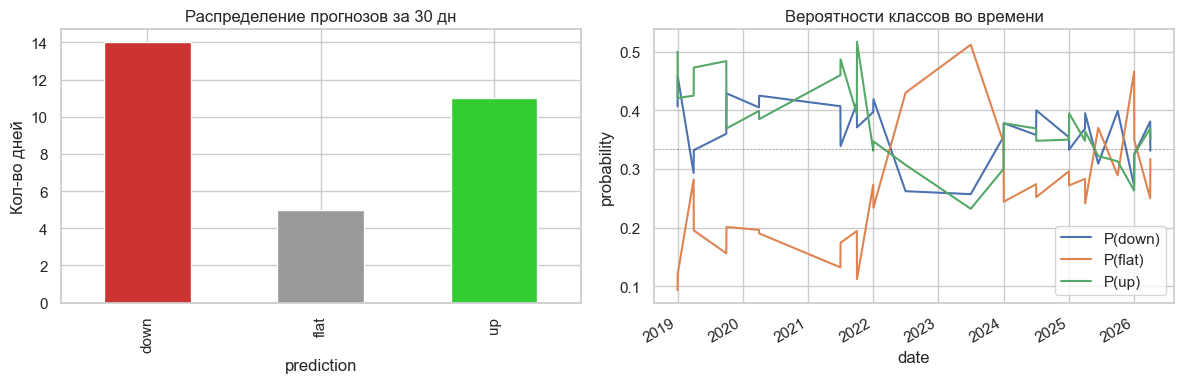

In [6]:
# распределение прогнозов
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
result['prediction'].value_counts().reindex(model.classes_).plot.bar(
    ax=axes[0], color=['#c33', '#999', '#3c3']
)
axes[0].set_title(f'Распределение прогнозов за {len(result)} дн')
axes[0].set_ylabel('Кол-во дней')

# вероятности по дням
proba_cols = [c for c in result.columns if c.startswith('P(')]
result.set_index('date')[proba_cols].plot(ax=axes[1])
axes[1].set_title('Вероятности классов во времени')
axes[1].set_ylabel('probability')
axes[1].axhline(1/3, color='k', lw=0.5, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()

## 7. Прогноз на ближайший торговый день

Это и есть production-инференс: берём самый последний день, для которого
у нас есть полный вектор фичей, и сообщаем класс + вероятности.

In [7]:
last_date = X_all.index.max()
x_last = X_all.iloc[[-1]]

pred_last = model.predict(x_last)[0]
proba_last = model.predict_proba(x_last)[0]

print(f'Прогноз для {ASSET}, on={last_date.date()}:')
print(f'  предсказанный класс: {pred_last}')
for c, p in zip(model.classes_, proba_last):
    bar = '█' * int(p * 30)
    print(f'  P({c:5s}) = {p:.3f}  {bar}')

print()
print('Интерпретация:')
print(f'- Tau (порог flat) = {meta["tau"]:.5f}')
print(f'- Класс up/down/flat относится к движению на горизонт {meta.get("horizon_days", 1)} дн')

Прогноз для btc, on=2026-04-02:
  предсказанный класс: up
  P(down ) = 0.331  █████████
  P(flat ) = 0.317  █████████
  P(up   ) = 0.352  ██████████

Интерпретация:
- Tau (порог flat) = 0.00339
- Класс up/down/flat относится к движению на горизонт 1 дн


## 8. Заметки по использованию

* PRD-версию можно поменять, сняв тег `stage=PRD` со старой модели и
  поставив на новую. Логика поиска в этом блокноте автоматически
  подхватит новую.
* Если перезапустить обучение с другим набором фичей (например, добавив
  `finbert_body=true`), `meta['features']` поменяется - и блокнот сам
  соберёт нужный набор колонок.
* Для CLI-инференса используется `src/inference/predict_cli.py` с теми
  же шагами и Hydra-конфигом `configs/inference/default.yaml`.